In [1]:
%matplotlib inline
## Setup: load joint library, deepLIFT attrs, compute (lfc, cossim) for the 56k.
import os, sys, numpy as np, pandas as pd, matplotlib.pyplot as plt

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import EigenMap, ENHANCER_LEN
ENH = ENHANCER_LEN

CT = {'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device='cpu')
em.load_from_dataframe(df, seq_col='sequence')

raw = np.load(os.path.join(REPO, 'genomic_targets/data/deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n_full = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{c}_log2FC' for c in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n_full][keep]
    em.attr_hyp[ct] = hyp
    em.attr[ct]     = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)

cossim = em.cosine_similarity(mode='importance', zscore=True)
lfc    = df['HepG2_log2FC'].values - df['K562_log2FC'].values
fin    = np.isfinite(cossim) & np.isfinite(lfc)
print(f'{len(df)} seqs   fin={fin.sum()}')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_twostep_v6_do075', 'HepG2': 'HepG2_twostep_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
56975 seqs   fin=56975


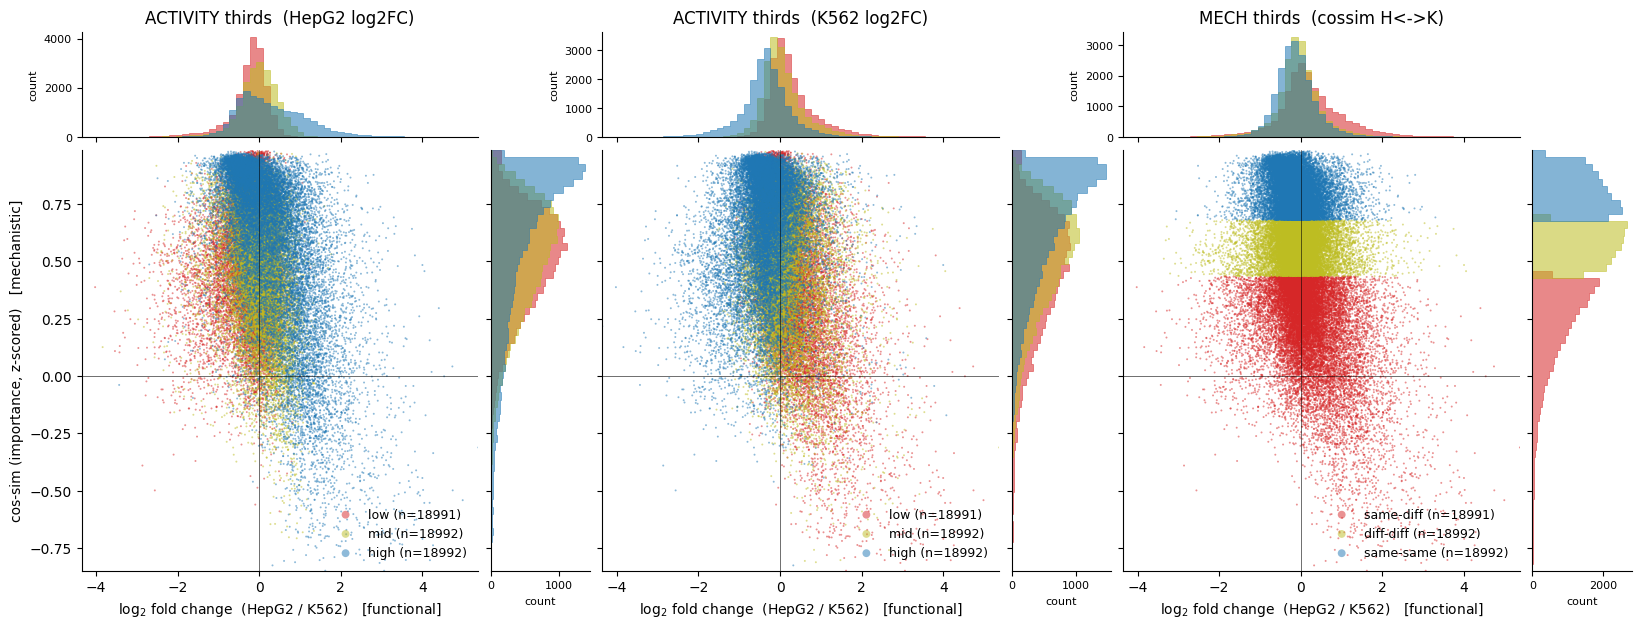

In [2]:
## 56k library on (lfc, cossim) -- three panels with marginal distributions (raw counts):
##   panel 1: HepG2 activity thirds  (per-ct log2FC equal-thirds, HepG2)
##   panel 2: K562  activity thirds  (per-ct log2FC equal-thirds, K562)
##   panel 3: MECH thirds            (cossim H<->K equal-thirds; symmetric)
ACT_LABELS   = ['low', 'mid', 'high']
MECH_LABELS  = ['same-diff', 'diff-diff', 'same-same']
COLORS       = ['#d62728', '#bdbd22', '#1f77b4']  # red / olive / blue

def thirds(values, fin_mask):
    idx = np.where(fin_mask)[0]
    order = idx[np.argsort(values[idx])]
    n = len(order); e = [0, n // 3, 2 * n // 3, n]
    masks = [np.zeros_like(fin_mask) for _ in range(3)]
    for i in range(3):
        masks[i][order[e[i]:e[i+1]]] = True
    return masks

hep_masks  = thirds(df['HepG2_log2FC'].values, fin)
k562_masks = thirds(df['K562_log2FC'].values,  fin)
mech_masks = thirds(cossim, fin)

x_lim = (np.nanmin(lfc[fin]),    np.nanmax(lfc[fin]))
y_lim = (np.nanmin(cossim[fin]), np.nanmax(cossim[fin]))
x_bins = np.linspace(*x_lim, 60)
y_bins = np.linspace(*y_lim, 60)

fig = plt.figure(figsize=(20, 7))
gs  = fig.add_gridspec(2, 6,
                       width_ratios=[4, 1, 4, 1, 4, 1],
                       height_ratios=[1, 4],
                       hspace=0.05, wspace=0.05)

panels = [
    (0, hep_masks,  ACT_LABELS,  'ACTIVITY thirds  (HepG2 log2FC)'),
    (2, k562_masks, ACT_LABELS,  'ACTIVITY thirds  (K562 log2FC)'),
    (4, mech_masks, MECH_LABELS, 'MECH thirds  (cossim H<->K)'),
]

scatter_axes = []
for col, masks, labels, title in panels:
    ax_main = fig.add_subplot(gs[1, col])
    ax_top  = fig.add_subplot(gs[0, col],     sharex=ax_main)
    ax_rt   = fig.add_subplot(gs[1, col + 1], sharey=ax_main)

    for m, lab, c in zip(masks, labels, COLORS):
        ax_main.scatter(lfc[m], cossim[m], s=2, c=c, alpha=0.5,
                        edgecolors='none', rasterized=True,
                        label=f'{lab} (n={m.sum()})')
        ax_top.hist(lfc[m],   bins=x_bins, color=c, alpha=0.55,
                    histtype='stepfilled', edgecolor=c, linewidth=0.6)
        ax_rt.hist(cossim[m], bins=y_bins, color=c, alpha=0.55,
                   histtype='stepfilled', edgecolor=c, linewidth=0.6,
                   orientation='horizontal')

    ax_main.axhline(0, color='k', lw=0.4); ax_main.axvline(0, color='k', lw=0.4)
    ax_main.set_xlabel('log$_2$ fold change  (HepG2 / K562)   [functional]')
    ax_main.set_xlim(x_lim); ax_main.set_ylim(y_lim)
    ax_main.legend(frameon=False, fontsize=9, loc='lower right', markerscale=4)
    for sp in ('top', 'right'): ax_main.spines[sp].set_visible(False)

    ax_top.set_title(title)
    ax_top.set_ylabel('count', fontsize=8)
    ax_rt.set_xlabel('count', fontsize=8)
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_rt.get_yticklabels(),  visible=False)
    ax_top.tick_params(axis='y', labelsize=8)
    ax_rt.tick_params(axis='x',  labelsize=8)
    for sp in ('top', 'right'):
        ax_top.spines[sp].set_visible(False); ax_rt.spines[sp].set_visible(False)

    scatter_axes.append(ax_main)

scatter_axes[0].set_ylabel('cos-sim (importance, z-scored)   [mechanistic]')
for ax in scatter_axes[1:]:
    plt.setp(ax.get_yticklabels(), visible=False)

plt.show()

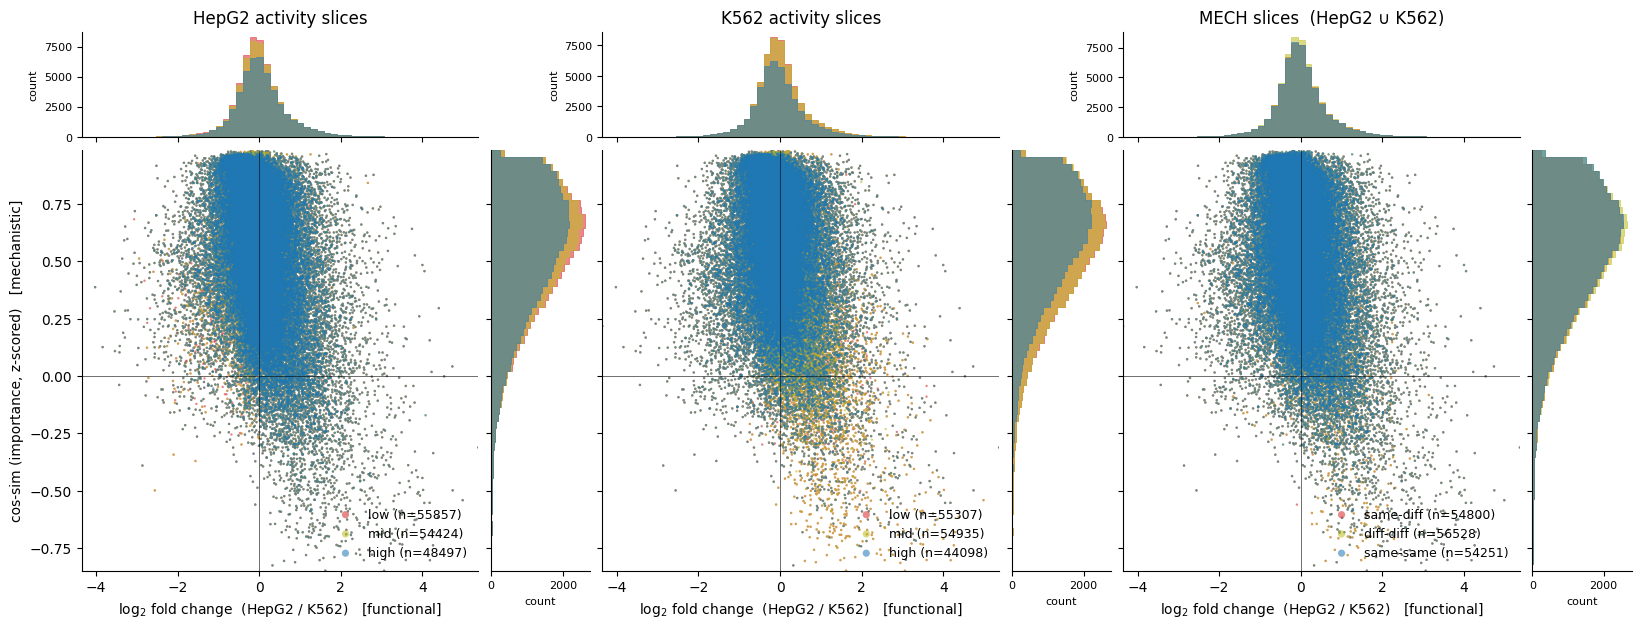

In [3]:
## Finemo hits per modisco slice on the (lfc, cossim) space, with marginal distributions (raw counts).
##   panel 1: HepG2 activity slices  (low/mid/high)
##   panel 2: K562  activity slices  (low/mid/high)
##   panel 3: MECH slices            (union of HepG2 and K562 mech hits per slice;
##                                    cossim thirds are symmetric across cts)
MOTIF_DIR = os.path.join(REPO, 'genomic_targets/data/motif')
ACT_SLICES  = ['low', 'mid', 'high']
MECH_SLICES = ['same-diff', 'diff-diff', 'same-same']
SLICE_COLORS = {'low':'#d62728', 'mid':'#bdbd22', 'high':'#1f77b4',
                'same-diff':'#d62728', 'diff-diff':'#bdbd22', 'same-same':'#1f77b4'}

def slice_hits_mask(ct, kind, slice_name, n):
    p = os.path.join(MOTIF_DIR, ct, f'{kind}_{slice_name}', 'hits.tsv')
    if not os.path.exists(p):
        print(f'  missing {p}'); return np.zeros(n, dtype=bool)
    h = pd.read_csv(p, sep='\t', usecols=['peak_id'])
    ids = h['peak_id'].astype(int).unique()
    ids = ids[ids < n]
    m = np.zeros(n, dtype=bool); m[ids] = True
    return m

n = len(df)
x_bins = np.linspace(*x_lim, 60); y_bins = np.linspace(*y_lim, 60)

fig = plt.figure(figsize=(20, 7))
gs  = fig.add_gridspec(2, 6, width_ratios=[4, 1, 4, 1, 4, 1],
                       height_ratios=[1, 4], hspace=0.05, wspace=0.05)

panels = [
    (0, [('HepG2', 'activity', s) for s in ACT_SLICES],  'HepG2 activity slices', ACT_SLICES),
    (2, [('K562',  'activity', s) for s in ACT_SLICES],  'K562 activity slices',  ACT_SLICES),
    (4, [(ct, 'mech', s) for s in MECH_SLICES for ct in ('HepG2','K562')],
        'MECH slices  (HepG2 ∪ K562)', MECH_SLICES),
]

scatter_axes = []
for col, runs, title, legend_slices in panels:
    ax_main = fig.add_subplot(gs[1, col])
    ax_top  = fig.add_subplot(gs[0, col],     sharex=ax_main)
    ax_rt   = fig.add_subplot(gs[1, col + 1], sharey=ax_main)

    ax_main.scatter(lfc[fin], cossim[fin], s=1, c='lightgrey', alpha=0.3,
                    edgecolors='none', rasterized=True)

    slice_to_mask = {}
    for ct, kind, sl in runs:
        m = slice_hits_mask(ct, kind, sl, n) & fin
        slice_to_mask[sl] = slice_to_mask.get(sl, np.zeros(n, dtype=bool)) | m

    for sl in legend_slices:
        m = slice_to_mask.get(sl, np.zeros(n, dtype=bool))
        c = SLICE_COLORS[sl]
        ax_main.scatter(lfc[m], cossim[m], s=3, c=c, alpha=0.55,
                        edgecolors='none', rasterized=True,
                        label=f'{sl} (n={m.sum()})')
        ax_top.hist(lfc[m],   bins=x_bins, color=c, alpha=0.55,
                    histtype='stepfilled', edgecolor=c, linewidth=0.6)
        ax_rt.hist(cossim[m], bins=y_bins, color=c, alpha=0.55,
                   histtype='stepfilled', edgecolor=c, linewidth=0.6,
                   orientation='horizontal')

    ax_main.axhline(0, color='k', lw=0.4); ax_main.axvline(0, color='k', lw=0.4)
    ax_main.set_xlim(x_lim); ax_main.set_ylim(y_lim)
    ax_main.set_xlabel('log$_2$ fold change  (HepG2 / K562)   [functional]')
    ax_main.legend(frameon=False, fontsize=9, loc='lower right', markerscale=3)
    for sp in ('top', 'right'): ax_main.spines[sp].set_visible(False)

    ax_top.set_title(title)
    ax_top.set_ylabel('count', fontsize=8)
    ax_rt.set_xlabel('count', fontsize=8)
    plt.setp(ax_top.get_xticklabels(), visible=False)
    plt.setp(ax_rt.get_yticklabels(),  visible=False)
    ax_top.tick_params(axis='y', labelsize=8)
    ax_rt.tick_params(axis='x',  labelsize=8)
    for sp in ('top', 'right'):
        ax_top.spines[sp].set_visible(False); ax_rt.spines[sp].set_visible(False)

    scatter_axes.append(ax_main)

scatter_axes[0].set_ylabel('cos-sim (importance, z-scored)   [mechanistic]')
for ax in scatter_axes[1:]:
    plt.setp(ax.get_yticklabels(), visible=False)

plt.show()

seqs with hits in HepG2: 52377/56975   K562: 51208/56975
seqs with hits in EITHER ct: 55896/56975   in BOTH: 47689/56975
mean % overlap: 40.1%   median: 42.4%


/tmp/slurm_tmp/2101249/ipykernel_2964604/656234768.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


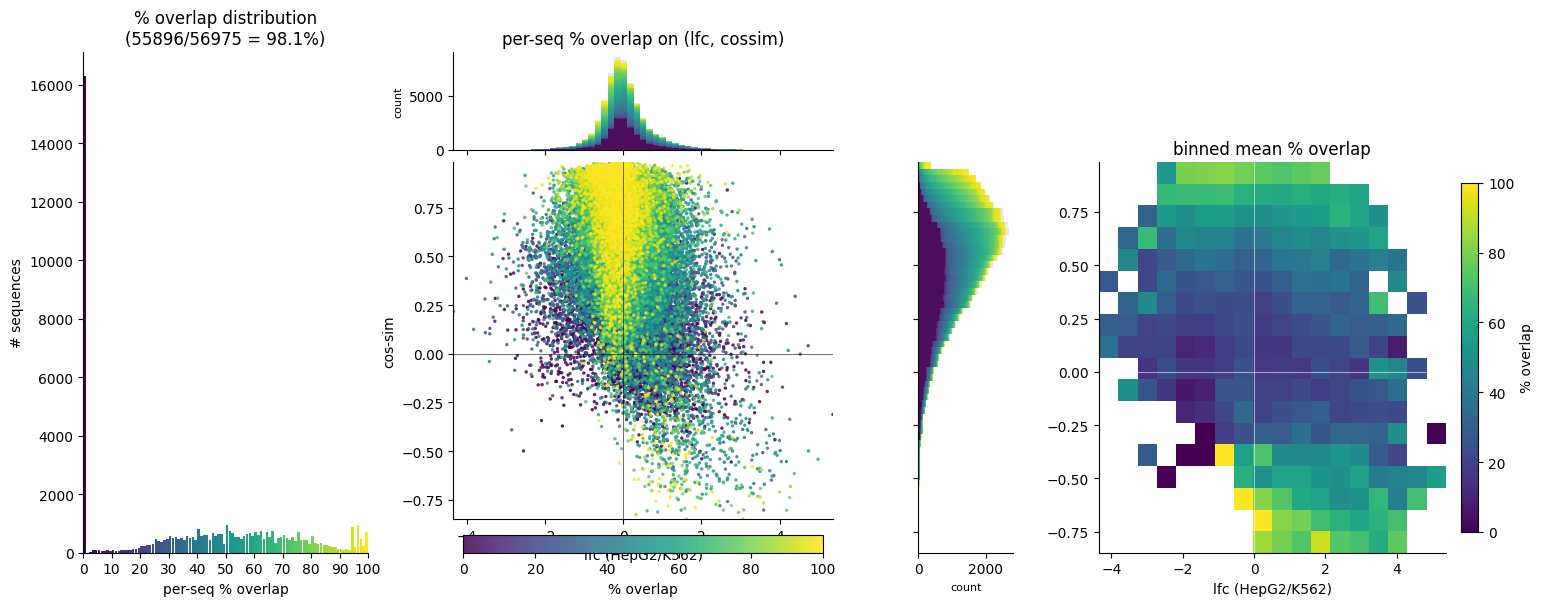


mean % overlap by mech third:
  same-diff   n= 18740  pct = 23.2%
  diff-diff   n= 18458  pct = 35.6%
  same-same   n= 18698  pct = 61.5%

mean % overlap by func third (lfc):
  K562-spec   n= 18605  pct = 46.7%
  balanced    n= 18407  pct = 38.1%
  HepG2-spec  n= 18884  pct = 35.6%


In [4]:
## Cross-cell-line agreement on FINEMO motif POSITIONS, per sequence (along the same seq).
## Per-seq Sørensen-Dice % overlap = 100 * 2|H ∩ K| / (|H| + |K|), one scalar per sequence.
## Marginal histograms are STACKED by overlap-% bin (1% bins, viridis), raw counts. No legend.
HITS = {
    'HepG2': os.path.join(REPO, 'genomic_targets/data/motif/HepG2/hits.tsv'),
    'K562':  os.path.join(REPO, 'genomic_targets/data/motif/K562/hits.tsv'),
}
REGIONS = {
    'HepG2': os.path.join(REPO, 'genomic_targets/data/motif/HepG2/regions.npz'),
    'K562':  os.path.join(REPO, 'genomic_targets/data/motif/K562/regions.npz'),
}

n = len(df); W = ENH

def occupancy(hits_path, regions_path):
    reg = np.load(regions_path, allow_pickle=True)
    region_start = np.asarray(reg['start']).astype(np.int64)
    h = pd.read_csv(hits_path, sep='\t', usecols=['peak_id', 'start', 'end'])
    h = h[(h['peak_id'] >= 0) & (h['peak_id'] < n)]
    pid = h['peak_id'].astype(int).values
    rel_st = np.clip(h['start'].astype(int).values - region_start[pid], 0, W)
    rel_en = np.clip(h['end'  ].astype(int).values - region_start[pid], 0, W)
    occ = np.zeros((n, W), dtype=bool)
    for p, st, en in zip(pid, rel_st, rel_en):
        if en > st:
            occ[p, st:en] = True
    return occ

occ_H = occupancy(HITS['HepG2'], REGIONS['HepG2'])
occ_K = occupancy(HITS['K562'],  REGIONS['K562'])

H_bp = occ_H.sum(axis=1); K_bp = occ_K.sum(axis=1)
inter = (occ_H & occ_K).sum(axis=1)
denom = H_bp + K_bp
overlap_pct = np.where(denom > 0, 100.0 * 2 * inter / np.maximum(denom, 1), np.nan)

has_any = denom > 0
print(f'seqs with hits in HepG2: {(H_bp>0).sum()}/{n}   K562: {(K_bp>0).sum()}/{n}')
print(f'seqs with hits in EITHER ct: {has_any.sum()}/{n}   in BOTH: {((H_bp>0)&(K_bp>0)).sum()}/{n}')
print(f'mean % overlap: {np.nanmean(overlap_pct):.1f}%   median: {np.nanmedian(overlap_pct):.1f}%')

OVL_EDGES  = np.arange(0, 101, 1)   # 1% bins
viridis = plt.get_cmap('viridis')
OVL_COLORS = [viridis((OVL_EDGES[i] + OVL_EDGES[i+1]) / 200.0) for i in range(len(OVL_EDGES) - 1)]

fig = plt.figure(figsize=(18, 6.5))
gs = fig.add_gridspec(2, 4, width_ratios=[3, 4, 1, 4],
                      height_ratios=[1, 4], hspace=0.05, wspace=0.3)

# ----- Panel A: % overlap histogram (raw counts), bars colored by viridis bin -----
ax_a = fig.add_subplot(gs[:, 0])
counts, _ = np.histogram(overlap_pct[has_any], bins=OVL_EDGES)
centers = (OVL_EDGES[:-1] + OVL_EDGES[1:]) / 2
ax_a.bar(centers, counts, width=0.9, color=OVL_COLORS, edgecolor='none')
ax_a.set_xlabel('per-seq % overlap'); ax_a.set_ylabel('# sequences')
ax_a.set_xlim(0, 100)
ax_a.set_xticks(np.arange(0, 101, 10))
ax_a.set_title(f'% overlap distribution\n({has_any.sum()}/{n} = {has_any.sum()/n:.1%})')
for sp in ('top', 'right'): ax_a.spines[sp].set_visible(False)

# ----- Panel B: scatter + STACKED marginals colored by overlap bin (no legend) -----
ax_main = fig.add_subplot(gs[1, 1])
ax_top  = fig.add_subplot(gs[0, 1], sharex=ax_main)
ax_rt   = fig.add_subplot(gs[1, 2], sharey=ax_main)

sel = fin & has_any
order = np.argsort(overlap_pct[sel])
xs, ys, cs = lfc[sel][order], cossim[sel][order], overlap_pct[sel][order]
ax_main.scatter(lfc[fin & ~has_any], cossim[fin & ~has_any], s=2, c='lightgrey',
                alpha=0.4, edgecolors='none', rasterized=True)
sc = ax_main.scatter(xs, ys, c=cs, cmap='viridis', vmin=0, vmax=100,
                     s=6, alpha=0.85, edgecolors='none', rasterized=True)
ax_main.axhline(0, color='k', lw=0.4); ax_main.axvline(0, color='k', lw=0.4)
ax_main.set_xlabel('lfc (HepG2/K562)'); ax_main.set_ylabel('cos-sim')
ax_main.set_xlim(x_lim); ax_main.set_ylim(y_lim)
plt.colorbar(sc, ax=ax_main, fraction=0.046, pad=0.04, label='% overlap',
             location='bottom')
for sp in ('top', 'right'): ax_main.spines[sp].set_visible(False)

x_bins = np.linspace(*x_lim, 60); y_bins = np.linspace(*y_lim, 60)
bin_idx = np.digitize(overlap_pct, OVL_EDGES) - 1
bin_idx = np.clip(bin_idx, 0, len(OVL_EDGES) - 2)
stack_lfc = [lfc[sel & (bin_idx == i)] for i in range(len(OVL_EDGES) - 1)]
stack_cs  = [cossim[sel & (bin_idx == i)] for i in range(len(OVL_EDGES) - 1)]

ax_top.hist(lfc[fin],   bins=x_bins, color='lightgrey',
            histtype='stepfilled', alpha=0.5)
ax_top.hist(stack_lfc,  bins=x_bins, stacked=True,
            color=OVL_COLORS, alpha=0.95,
            histtype='stepfilled', edgecolor='none')

ax_rt.hist(cossim[fin], bins=y_bins, color='lightgrey',
           histtype='stepfilled', alpha=0.5, orientation='horizontal')
ax_rt.hist(stack_cs,    bins=y_bins, stacked=True,
           color=OVL_COLORS, alpha=0.95, histtype='stepfilled', edgecolor='none',
           orientation='horizontal')

ax_top.set_title('per-seq % overlap on (lfc, cossim)')
ax_top.set_ylabel('count', fontsize=8)
ax_rt.set_xlabel('count', fontsize=8)
plt.setp(ax_top.get_xticklabels(), visible=False)
plt.setp(ax_rt.get_yticklabels(),  visible=False)
for sp in ('top', 'right'):
    ax_top.spines[sp].set_visible(False); ax_rt.spines[sp].set_visible(False)

# ----- Panel C: binned mean % overlap heatmap -----
ax_c = fig.add_subplot(gs[1, 3], sharex=ax_main, sharey=ax_main)
nbins = 18
xb = np.linspace(*x_lim, nbins + 1)
yb = np.linspace(*y_lim, nbins + 1)
H_sum, _, _ = np.histogram2d(lfc[sel], cossim[sel], bins=[xb, yb], weights=overlap_pct[sel])
H_cnt, _, _ = np.histogram2d(lfc[sel], cossim[sel], bins=[xb, yb])
mean_pct = np.where(H_cnt > 0, H_sum / np.maximum(H_cnt, 1), np.nan)
im = ax_c.imshow(mean_pct.T, origin='lower', extent=(xb[0], xb[-1], yb[0], yb[-1]),
                 aspect='auto', cmap='viridis', vmin=0, vmax=100)
ax_c.axhline(0, color='w', lw=0.4); ax_c.axvline(0, color='w', lw=0.4)
ax_c.set_xlabel('lfc (HepG2/K562)')
ax_c.set_title('binned mean % overlap')
plt.colorbar(im, ax=ax_c, fraction=0.046, pad=0.04, label='% overlap')
for sp in ('top', 'right'): ax_c.spines[sp].set_visible(False)

plt.tight_layout(); plt.show()

mech_t = thirds(cossim, fin)
func_t = thirds(lfc, fin)
print('\nmean % overlap by mech third:')
for sl, m in zip(MECH_SLICES, mech_t):
    s = m & has_any & fin
    print(f'  {sl:10s}  n={s.sum():6d}  pct = {np.nanmean(overlap_pct[s]):.1f}%')
print('\nmean % overlap by func third (lfc):')
for sl, m in zip(['K562-spec', 'balanced', 'HepG2-spec'], func_t):
    s = m & has_any & fin
    print(f'  {sl:10s}  n={s.sum():6d}  pct = {np.nanmean(overlap_pct[s]):.1f}%')